In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [3]:
df_port = pd.read_csv("../dataset/portfolio.csv")
df_prof = pd.read_csv("../dataset/profile.csv")
df_tran = pd.read_csv("../dataset/transcript.csv")
df_menu = pd.read_csv("../dataset/starbucks_menu_260112.csv")
print("프로모션 제공 데이터 크기:", df_port.shape)
print("고객정보 데이터 크기:", df_prof.shape)
print("제공 프로모션 데이터 크기:", df_tran.shape)
print("메뉴 정보 데이터 크기:", df_menu.shape)

프로모션 제공 데이터 크기: (10, 7)
고객정보 데이터 크기: (17000, 6)
제공 프로모션 데이터 크기: (306534, 5)
메뉴 정보 데이터 크기: (195, 13)


In [4]:
df_port.head()

,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7


In [5]:
df_prof.head()

,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.00
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.00
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [6]:
df_tran.head()

,Unnamed: 0,person,event,value,time
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [ ]:
df_menu.head()

,Unnamed: 0,제품코드,제품명,1회 제공량(kcal),포화지방(g),단백질(g),지방(g),트랜스지방(g),나트륨(mg),당류(g),카페인(mg),콜레스테롤(mg),탄수화물(g)
0,0,9200000002487,나이트로 바닐라 크림,80,2,1,2.7,0,40,10,232,5,10
1,1,9200000000479,나이트로 콜드 브루,5,0,0,0,0,5,0,245,0,0
2,2,9200000002081,돌체 콜드 브루,220,6,6,10,0,80,22,155,20,24
3,3,9200000002407,리저브 나이트로,5,0,0,0,0,0,0,190,0,0
4,4,9200000002093,리저브 콜드 브루,5,0,0,0,0,0,0,190,0,0


### df_port (portfolio) 부터 전처리 시작
- 어떤 오퍼를 보냈는지에 대한 정의 테이블

> 기본 점검 3단계 (head, info, describe)

| 컬럼         | 의미                              |
| ---------- | ------------------------------- |
| id         | offer_id (핵심 키)                |
| offer_type | bogo / discount / informational |
| difficulty | 최소 소비 금액                        |
| reward     | 보상 금액                           |
| duration   | 유효 기간 (일)                       |
| channels   | 전달 채널 리스트                       |

In [ ]:
df_port

,Unnamed: 0,reward,channels,difficulty,duration,offer_type,id
0,0,10,"['email', 'mobile', 'social']",10,7,bogo,ae264e3637204a6fb9bb56bc8210ddfd
1,1,10,"['web', 'email', 'mobile', 'social']",10,5,bogo,4d5c57ea9a6940dd891ad53e9dbe8da0
2,2,0,"['web', 'email', 'mobile']",0,4,informational,3f207df678b143eea3cee63160fa8bed
3,3,5,"['web', 'email', 'mobile']",5,7,bogo,9b98b8c7a33c4b65b9aebfe6a799e6d9
4,4,5,"['web', 'email']",20,10,discount,0b1e1539f2cc45b7b9fa7c272da2e1d7
5,5,3,"['web', 'email', 'mobile', 'social']",7,7,discount,2298d6c36e964ae4a3e7e9706d1fb8c2
6,6,2,"['web', 'email', 'mobile', 'social']",10,10,discount,fafdcd668e3743c1bb461111dcafc2a4
7,7,0,"['email', 'mobile', 'social']",0,3,informational,5a8bc65990b245e5a138643cd4eb9837
8,8,5,"['web', 'email', 'mobile', 'social']",5,5,bogo,f19421c1d4aa40978ebb69ca19b0e20d
9,9,2,"['web', 'email', 'mobile']",10,7,discount,2906b810c7d4411798c6938adc9daaa5


In [ ]:
df_port.info()
#Unnamed : 0 제외?
#문자형 3 숫자형 3


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  10 non-null     int64
 1   reward      10 non-null     int64
 2   channels    10 non-null     str  
 3   difficulty  10 non-null     int64
 4   duration    10 non-null     int64
 5   offer_type  10 non-null     str  
 6   id          10 non-null     str  
dtypes: int64(4), str(3)
memory usage: 692.0 bytes


In [ ]:
df_port.describe()
#reward | difficulty | duration
#문제없음

,Unnamed: 0,reward,difficulty,duration
count,10.00,10.00,10.00,10.00
mean,4.50,4.20,7.70,6.50
std,3.03,3.58,5.83,2.32
min,0.00,0.00,0.00,3.00
25%,2.25,2.00,5.00,5.00
50%,4.50,4.00,8.50,7.00
75%,6.75,5.00,10.00,7.00
max,9.00,10.00,20.00,10.00


> 결측치 & 중복값 탐색

In [ ]:
df_port.isna().sum()
#결측 없고

Unnamed: 0    0
reward        0
channels      0
difficulty    0
duration      0
offer_type    0
id            0
dtype: int64

In [ ]:
df_port.duplicated().sum()
#중복 없고

np.int64(0)

>  channels | offer_type | id        분포확인

In [ ]:
df_port['channels'].value_counts()
#리스트 나눠줘야겠는데

channels
['web', 'email', 'mobile', 'social']    4
['web', 'email', 'mobile']              3
['email', 'mobile', 'social']           2
['web', 'email']                        1
Name: count, dtype: int64

In [ ]:
df_port['offer_type'].value_counts()

offer_type
bogo             4
discount         4
informational    2
Name: count, dtype: int64

In [ ]:
df_port['id'].value_counts()

id
ae264e3637204a6fb9bb56bc8210ddfd    1
4d5c57ea9a6940dd891ad53e9dbe8da0    1
3f207df678b143eea3cee63160fa8bed    1
9b98b8c7a33c4b65b9aebfe6a799e6d9    1
0b1e1539f2cc45b7b9fa7c272da2e1d7    1
2298d6c36e964ae4a3e7e9706d1fb8c2    1
fafdcd668e3743c1bb461111dcafc2a4    1
5a8bc65990b245e5a138643cd4eb9837    1
f19421c1d4aa40978ebb69ca19b0e20d    1
2906b810c7d4411798c6938adc9daaa5    1
Name: count, dtype: int64

> channels 컬럼 처리 One-hot encoding

In [ ]:
df_port['ch_web'] = df_port['channels'].apply(lambda x: 1 if 'web' in x else 0)
df_port['ch_email'] = df_port['channels'].apply(lambda x: 1 if 'email' in x else 0)
df_port['ch_mobile'] = df_port['channels'].apply(lambda x: 1 if 'mobile' in x else 0)
df_port['ch_social'] = df_port['channels'].apply(lambda x: 1 if 'social' in x else 0)

In [ ]:
df_port['channel_count'] = (
    df_port['ch_web'] +
    df_port['ch_email'] +
    df_port['ch_mobile'] +
    df_port['ch_social']
)

df_port['channel_count']

#오퍼 채널 수에 따른 효과 검증용 컬럼

0    3
1    4
2    3
3    3
4    2
5    4
6    4
7    3
8    4
9    3
Name: channel_count, dtype: int64

In [ ]:
#기존 channel 컬럼 삭제
df_port = df_port.drop(columns = ['channels'])

> 컬럼 정리 with 파생컬럼

In [ ]:
df_port = df_port.drop(columns=['Unnamed: 0'])
df_port.columns

Index(['reward', 'difficulty', 'duration', 'offer_type', 'id', 'ch_web',
       'ch_email', 'ch_mobile', 'ch_social', 'channel_count'],
      dtype='str')

In [ ]:
df_port['reward_ratio'] = np.where(
    df_port['difficulty'] == 0,
    df_port['reward'],
    df_port['reward'] / df_port['difficulty']
)
df_port['reward_ratio']

0   1.00
1   1.00
2   0.00
3   1.00
4   0.25
5   0.43
6   0.20
7   0.00
8   1.00
9   0.20
Name: reward_ratio, dtype: float64

In [ ]:
df_port['offer_strength'] = df_port['reward'] - df_port['difficulty']
df_port['offer_strength']

0     0
1     0
2     0
3     0
4   -15
5    -4
6    -8
7     0
8     0
9    -8
Name: offer_strength, dtype: int64

In [ ]:
df_port = df_port.rename(columns={'id' : 'offer_id'})

> 최종 확인

In [ ]:
df_port.groupby('offer_type')[['reward','difficulty','duration']].mean()

,reward,difficulty,duration
offer_type,,,
bogo,7.50,7.50,6.00
discount,3.00,11.75,8.50
informational,0.00,0.00,3.50


In [ ]:
df_port.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   reward          10 non-null     int64  
 1   difficulty      10 non-null     int64  
 2   duration        10 non-null     int64  
 3   offer_type      10 non-null     str    
 4   offer_id        10 non-null     str    
 5   ch_web          10 non-null     int64  
 6   ch_email        10 non-null     int64  
 7   ch_mobile       10 non-null     int64  
 8   ch_social       10 non-null     int64  
 9   channel_count   10 non-null     int64  
 10  reward_ratio    10 non-null     float64
 11  offer_strength  10 non-null     int64  
dtypes: float64(1), int64(9), str(2)
memory usage: 1.1 KB


### df_tran (transcript) 전처리 시작
- 고객이 언제 어떤 행동(오퍼 수신·열람·완료·구매)을 했는지 기록한 이벤트 로그 테이블

> 기본 점검 3단계 (head, info, describe)

| 컬럼     | 의미              |
| ------ | --------------- |
| person | 고객 ID           |
| event  | 이벤트 종류          |
| value  | 상세 정보 (딕셔너리 형태) |
| time   | 발생 시간 (시간 단위)   |


In [ ]:
df_tran.head()

,Unnamed: 0,person,event,value,time
0,0,78afa995795e4d85b5d9ceeca43f5fef,offer received,{'offer id': '9b98b8c7a33c4b65b9aebfe6a799e6d9'},0
1,1,a03223e636434f42ac4c3df47e8bac43,offer received,{'offer id': '0b1e1539f2cc45b7b9fa7c272da2e1d7'},0
2,2,e2127556f4f64592b11af22de27a7932,offer received,{'offer id': '2906b810c7d4411798c6938adc9daaa5'},0
3,3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'},0
4,4,68617ca6246f4fbc85e91a2a49552598,offer received,{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'},0


In [ ]:
df_tran.info()

<class 'pandas.DataFrame'>
RangeIndex: 306534 entries, 0 to 306533
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Unnamed: 0  306534 non-null  int64
 1   person      306534 non-null  str  
 2   event       306534 non-null  str  
 3   value       306534 non-null  str  
 4   time        306534 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.7 MB


In [ ]:
df_tran.describe()

,Unnamed: 0,time
count,306534.00,306534.00
mean,153266.50,366.38
std,88488.89,200.33
min,0.00,0.00
25%,76633.25,186.00
50%,153266.50,408.00
75%,229899.75,528.00
max,306533.00,714.00


> 결측치 & 중복값 확인

In [ ]:
df_tran.isna().sum()

Unnamed: 0    0
person        0
event         0
value         0
time          0
dtype: int64

In [ ]:
df_tran.duplicated().sum()

np.int64(0)

> str 형태 컬럼 분포확인 ( person | event | value)

In [ ]:
df_tran['person'].nunique()   #고객 몇명?

17000

In [ ]:
df_tran['person'].value_counts().head()

person
94de646f7b6041228ca7dec82adb97d2    51
8dbfa485249f409aa223a2130f40634a    49
79d9d4f86aca4bed9290350fb43817c2    48
d0a80415b84c4df4908b8403b19765e3    48
5e60c6aa3b834e44b822ea43a3efea26    48
Name: count, dtype: int64

In [ ]:
df_tran.groupby('person').size().describe()

count   17000.00
mean       18.03
std         6.85
min         1.00
25%        13.00
50%        17.00
75%        23.00
max        51.00
dtype: float64

In [ ]:
event_ratio = df_tran['event'].value_counts(normalize=True)*100
event_ratio
#transaction 45.33%
#offer received 24.88%
#offer viewed 18.83%
#offer completed 10.95%

event
transaction       45.33
offer received    24.88
offer viewed      18.83
offer completed   10.95
Name: proportion, dtype: float64

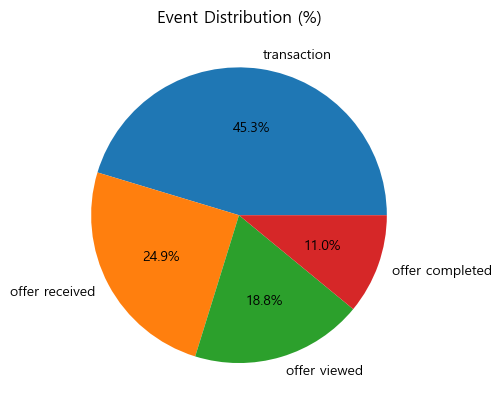

In [ ]:
#tableau 시각화 하면 좋을듯? 

plt.figure()

event_ratio.plot(kind='pie', autopct='%.1f%%')

plt.title('Event Distribution (%)')
plt.ylabel('')

plt.show()

> value 컬럼이 JSON 형태라서 분석이 어려워, 주요 변수인 offer_id와 amount를 컬럼으로 분리함
>> 퍼널 및 매출 분석 가능

In [ ]:
df_tran['value'].value_counts()

value
{'offer id': '2298d6c36e964ae4a3e7e9706d1fb8c2'}    14983
{'offer id': 'fafdcd668e3743c1bb461111dcafc2a4'}    14924
{'offer id': '4d5c57ea9a6940dd891ad53e9dbe8da0'}    14891
{'offer id': 'f19421c1d4aa40978ebb69ca19b0e20d'}    14835
{'offer id': 'ae264e3637204a6fb9bb56bc8210ddfd'}    14374
                                                    ...  
{'amount': 290.93}                                      1
{'amount': 43.91}                                       1
{'amount': 685.07}                                      1
{'amount': 405.04}                                      1
{'amount': 476.33}                                      1
Name: count, Length: 5121, dtype: int64

In [ ]:
#문자열 딕셔너리 변환

import ast

df_tran['value'] = df_tran['value'].apply(ast.literal_eval)

In [ ]:
df_tran['value'].apply(lambda x: list(x.keys())[0]).value_counts()

value
amount      138953
offer id    134002
offer_id     33579
Name: count, dtype: int64

In [ ]:
df_tran['offer_id'] = df_tran['value'].apply(lambda x: x.get('offer id') or x.get('offer_id'))
df_tran['amount'] = df_tran['value'].apply(lambda x: x.get('amount'))

In [ ]:
df_tran['offer_id'].isna().sum()

np.int64(138953)

In [ ]:
df_tran['amount'].isna().sum()

np.int64(167581)

In [ ]:
df_tran.groupby('event')[['offer_id', 'amount']].count()

,offer_id,amount
event,,
offer completed,33579,0
offer received,76277,0
offer viewed,57725,0
transaction,0,138953


### 컬럼 정리

In [ ]:
df_tran = df_tran.drop(columns=['value'])
df_tran = df_tran.drop(columns=['Unnamed: 0'])
df_tran = df_tran.rename(columns = {'person':'customer_id'})
df_tran.columns

Index(['customer_id', 'event', 'time', 'offer_id', 'amount'], dtype='str')

### df_prof (profile)전처리 시작

> 기본 점검 3단계 (head, info, describe)

| 컬럼               | 의미    |
| ---------------- | ----- |
| id               | 고객 ID |
| age              | 나이    |
| gender           | 성별    |
| income           | 연소득   |
| became_member_on | 가입일   |


In [ ]:
df_prof.head()

,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
1,1,F,55,0610b486422d4921ae7d2bf64640c50b,20170715,112000.00
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
3,3,F,75,78afa995795e4d85b5d9ceeca43f5fef,20170509,100000.00
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN


In [ ]:
df_prof.info()

<class 'pandas.DataFrame'>
RangeIndex: 17000 entries, 0 to 16999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        17000 non-null  int64  
 1   gender            14825 non-null  str    
 2   age               17000 non-null  int64  
 3   id                17000 non-null  str    
 4   became_member_on  17000 non-null  int64  
 5   income            14825 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 797.0 KB


In [ ]:
df_prof.describe()

,Unnamed: 0,age,became_member_on,income
count,17000.00,17000.00,17000.00,14825.00
mean,8499.50,62.53,20167034.23,65404.99
std,4907.62,26.74,11677.50,21598.30
min,0.00,18.00,20130729.00,30000.00
25%,4249.75,45.00,20160526.00,49000.00
50%,8499.50,58.00,20170802.00,64000.00
75%,12749.25,73.00,20171230.00,80000.00
max,16999.00,118.00,20180726.00,120000.00


> 결측치&중복값 확인

In [ ]:
df_prof.isna().sum()

Unnamed: 0             0
gender              2175
age                    0
id                     0
became_member_on       0
income              2175
dtype: int64

In [ ]:
df_prof[(df_prof['gender'].isna()) & (df_prof['income'].isna()) & (df_prof['age']==118)]

,Unnamed: 0,gender,age,id,became_member_on,income
0,0,NaN,118,68be06ca386d4c31939f3a4f0e3dd783,20170212,NaN
2,2,NaN,118,38fe809add3b4fcf9315a9694bb96ff5,20180712,NaN
4,4,NaN,118,a03223e636434f42ac4c3df47e8bac43,20170804,NaN
6,6,NaN,118,8ec6ce2a7e7949b1bf142def7d0e0586,20170925,NaN
7,7,NaN,118,68617ca6246f4fbc85e91a2a49552598,20171002,NaN
...,...,...,...,...,...,...
16980,16980,NaN,118,5c686d09ca4d475a8f750f2ba07e0440,20160901,NaN
16982,16982,NaN,118,d9ca82f550ac4ee58b6299cf1e5c824a,20160415,NaN
16989,16989,NaN,118,ca45ee1883624304bac1e4c8a114f045,20180305,NaN
16991,16991,NaN,118,a9a20fa8b5504360beb4e7c8712f8306,20160116,NaN


In [ ]:
df_prof[(df_prof['gender'].isna()) & (df_prof['income'].isna())]['age'].value_counts()

age
118    2175
Name: count, dtype: int64

In [ ]:
df_prof['age'] = df_prof['age'].replace(118, np.nan)

In [ ]:
(df_prof.isna().mean()*100).sort_values(ascending=False)
#날리면 데이터 손실 클 듯?
#특정 고객 유형으로 따로 분류하는게 나을 듯. 같은 결측 개수, 같은 특성을 보이고 있음
#gender(성별) → 'Unknown'
#income(연봉) → 0
#age(나이) → median

gender             12.79
age                12.79
income             12.79
Unnamed: 0          0.00
id                  0.00
became_member_on    0.00
dtype: float64

In [ ]:
df_prof['age'] = df_prof['age'].replace(118, np.nan)

df_prof['gender'] = df_prof['gender'].fillna('Unknown')

df_prof['income'] = df_prof['income'].fillna(0)

In [ ]:
df_prof['is_profile_missing'] = np.where(
    (df_prof['gender'] == 'Unknown') &
    (df_prof['income'] == 0) &
    (df_prof['age'].isna()),
    1, 0
)
(df_prof['is_profile_missing']==1).sum()        #1=true | 0=false

np.int64(2175)

In [ ]:
df_prof.duplicated().sum()
#중복 없음

np.int64(0)

In [ ]:
df_prof['gender'].value_counts()

gender
M          8484
F          6129
Unknown    2175
O           212
Name: count, dtype: int64

In [ ]:
df_prof['became_member_on']
#날짜 타입 변환 필요

0        20170212
1        20170715
2        20180712
3        20170509
4        20170804
           ...   
16995    20180604
16996    20180713
16997    20170126
16998    20160307
16999    20170722
Name: became_member_on, Length: 17000, dtype: int64

In [ ]:
df_prof['became_member_on'] = pd.to_datetime(df_prof['became_member_on'], format='%Y%m%d')
df_prof['became_member_on'].dtypes

dtype('<M8[us]')

In [ ]:
reference_date = df_prof['became_member_on'].max()

df_prof['membership_days'] = (
    reference_date - df_prof['became_member_on']
).dt.days

In [ ]:
def age_group(age):
    if pd.isna(age):
        return 'Unknown'
    elif age < 20:
        return '20대 미만'
    elif age < 30:
        return '20대'
    elif age < 40:
        return '30대'
    elif age < 50:
        return '40대'
    elif age < 60:
        return '50대'
    else:
        return '60대 이상'

df_prof['age_group'] = df_prof['age'].apply(age_group)

In [ ]:
#소득구간 파생변수로
# income mean:65404.9
# income min: 30000.0
# income max: 120000.0
def income_group(income):
    if income == 0:
        return 'Unknown'
    elif income < 50000:
        return '5만 미만'
    elif income < 75000:
        return '5-7.5만'
    elif income < 100000:
        return '7.5-10만'
    else:
        return '10만 이상'
df_prof['income_group'] = df_prof['income'].apply(income_group)

# before merge final checklist

In [ ]:
print(df_port['offer_id'].dtype)
print(df_tran['offer_id'].dtype)
#키 dtype 확인

str
str


In [ ]:
df_port['offer_id'] = df_port['offer_id'].astype(str)
df_tran['offer_id'] = df_tran['offer_id'].astype(str)
#혹시모르니까 한번 더 강제 통일

In [ ]:
df_prof = df_prof.rename(columns={'id': 'customer_id'})
df_prof['customer_id'] = df_prof['customer_id'].astype(str)
df_tran['customer_id'] = df_tran['customer_id'].astype(str)

In [ ]:
print(df_tran['customer_id'].dtype)
print(df_prof['customer_id'].dtype)

str
str


In [ ]:
(df_prof['income_group'].value_counts(normalize=True)*100).to_dict()

{'5-7.5만': 37.917647058823526,
 '5만 미만': 22.241176470588236,
 '7.5-10만': 20.61764705882353,
 'Unknown': 12.794117647058822,
 '10만 이상': 6.429411764705882}

In [ ]:
(df_prof['age_group'].value_counts(normalize=True)*100).to_dict()

{'60대 이상': 34.55882352941176,
 '50대': 20.82941176470588,
 '40대': 13.58235294117647,
 'Unknown': 12.794117647058822,
 '30대': 8.976470588235294,
 '20대': 8.052941176470588,
 '20대 미만': 1.2058823529411764}

#Merge 슛

In [ ]:
df = df_tran.merge(
    df_port,
    on='offer_id',
    how='left'
)

In [ ]:
df = df.merge(
    df_prof,
    on='customer_id',
    how='left'
)

In [ ]:
df.head()

,customer_id,event,time,offer_id,amount,reward,difficulty,duration,offer_type,ch_web,...,offer_strength,Unnamed: 0,gender,age,became_member_on,income,is_profile_missing,membership_days,age_group,income_group
0,78afa995795e4d85b5d9ceeca43f5fef,offer received,0,9b98b8c7a33c4b65b9aebfe6a799e6d9,NaN,5.00,5.00,7.00,bogo,1.00,...,0.00,3,F,75.00,2017-05-09,100000.00,0,443,60대 이상,10만 이상
1,a03223e636434f42ac4c3df47e8bac43,offer received,0,0b1e1539f2cc45b7b9fa7c272da2e1d7,NaN,5.00,20.00,10.00,discount,1.00,...,-15.00,4,Unknown,NaN,2017-08-04,0.00,1,356,Unknown,Unknown
2,e2127556f4f64592b11af22de27a7932,offer received,0,2906b810c7d4411798c6938adc9daaa5,NaN,2.00,10.00,7.00,discount,1.00,...,-8.00,5,M,68.00,2018-04-26,70000.00,0,91,60대 이상,5-7.5만
3,8ec6ce2a7e7949b1bf142def7d0e0586,offer received,0,fafdcd668e3743c1bb461111dcafc2a4,NaN,2.00,10.00,10.00,discount,1.00,...,-8.00,6,Unknown,NaN,2017-09-25,0.00,1,304,Unknown,Unknown
4,68617ca6246f4fbc85e91a2a49552598,offer received,0,4d5c57ea9a6940dd891ad53e9dbe8da0,NaN,10.00,10.00,5.00,bogo,1.00,...,0.00,7,Unknown,NaN,2017-10-02,0.00,1,297,Unknown,Unknown


In [ ]:
df.shape

(306534, 25)

In [ ]:
df_tran.shape

(306534, 5)

In [ ]:
df.groupby('event')[['amount','offer_id']].count()

,amount,offer_id
event,,
offer completed,0,33579
offer received,0,76277
offer viewed,0,57725
transaction,138953,0


In [ ]:
df.isna().sum().sort_values(ascending=False)

amount                167581
duration              138953
offer_id              138953
difficulty            138953
reward                138953
offer_type            138953
ch_mobile             138953
ch_email              138953
ch_web                138953
channel_count         138953
reward_ratio          138953
offer_strength        138953
ch_social             138953
age                    33772
time                       0
customer_id                0
event                      0
Unnamed: 0                 0
gender                     0
became_member_on           0
income                     0
is_profile_missing         0
membership_days            0
age_group                  0
income_group               0
dtype: int64

In [ ]:
df.shape

(306534, 25)

In [ ]:
df.columns

Index(['customer_id', 'event', 'time', 'offer_id', 'amount', 'reward',
       'difficulty', 'duration', 'offer_type', 'ch_web', 'ch_email',
       'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio',
       'offer_strength', 'Unnamed: 0', 'gender', 'age', 'became_member_on',
       'income', 'is_profile_missing', 'membership_days', 'age_group',
       'income_group'],
      dtype='str')